<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Spin_Torque_Quantum_Control_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Primer on Spin-Torque Quantum Control

### Nomenclature and Parameter Definitions

The following table establishes the primary acronyms and symbols utilized within the theoretical framework and simulation.

| Parameter | Definition |
| --- | --- |
| **STT** | Spin-Transfer Torque (angular momentum transfer from a spin-polarized charge current) |
| **SOT** | Spin-Orbit Torque (angular momentum transfer generated by spin-orbit interaction from a charge current) |
| **FLT** | Field-Like Torque (an adiabatic exchange field driving coherent precession) |
| **DLT** | Damping-Like Torque (a non-adiabatic dissipative channel inducing spin alignment) |
| **$\hat{\rho}$** | The reduced density matrix of the quantum object |
| **$\hat{H}_{xc}$** | The Hamiltonian exchange term generated by virtual tunneling |
| **$\hat{L}_{n}$** | The Lindblad jump operator representing real charge transfer events |
| **$\Omega_{Q}$** | The transverse matrix element (coherent drive rate) applied to the target qubit |
| **$\Gamma$** | The aggregate decoherence rate (including dephasing, relaxation, and thermal noise) |
| **$\eta$** | The guard margin multiplier ensuring the drive rate exceeds the noise floor |

Because quantum states are highly susceptible to environmental degradation, manipulating a localized quantum object demands an exceptionally precise energy transfer mechanism. A spinful quantum dot (which serves as a highly localized zero-dimensional physical system) can interact with adjacent electronic reservoirs through quantum tunneling. When a supplied electrical current is spin-polarized, the traversing electrons carry an intrinsic angular momentum that they subsequently transfer to the localized quantum dot. This transferred angular momentum provides a targeted mechanism for quantum manipulation.

To rigorously model this interaction, scientists employ an open quantum system formalism. The localized dot occupies a minimal Hilbert space defined by four discrete states (an empty singlet, a doubly occupied singlet, and two singly occupied spin-doublet states). The system dynamics are governed by a reduced density matrix $\hat{\rho}$ evaluated through a Lindblad master equation

$$\frac{d\hat{\rho}}{dt}=-\frac{i}{\hbar}[\hat{H}_{0}+\hat{H}_{Z}+\hat{H}_{xc},\hat{\rho}]+\sum_{n,\alpha}\gamma_{n\alpha}(\hat{L}_{n}\hat{\rho}\hat{L}_{n}^{\dagger}-\frac{1}{2}\{\hat{L}_{n}^{\dagger}\hat{L}_{n},\hat{\rho}\})$$

This central equation successfully isolates the two distinct spin-torque phenomena. The Field-Like Torque enters the mathematical framework through the coherent Hamiltonian commutator as an exchange field ($\hat{H}_{xc}$) generated by virtual electron tunneling. Conversely, the Damping-Like Torque manifests within the dissipative sum through the Lindblad jump operators ($\hat{L}_{n}$), representing irreversible angular momentum transfer from real spin-selective charge tunneling.

When researchers propose using this driven spin accumulation as an actuator to manipulate a separate, nearby target qubit, the coupling feasibility depends on a strict mathematical inequality. The coherent drive rate $\Omega_{Q}$ must strictly exceed the target system's accumulated decoherence rates ($\Gamma_{2,Q}$, backaction, heating, charge noise, and quasiparticle poisoning) scaled by a protective margin $\eta$.

$$\Omega_{Q}\ge\eta(\Gamma_{2,Q}+\Gamma_{back}+\Gamma_{heat}+\Gamma_{charge}+\Gamma_{qp})$$

This theoretical foundation provides strong justification for deploying spintronic actuators near magnetic clusters, localized magnon modes, or ferromagnetic quantum dots. In such platforms, the actuator strongly couples to the target's spinful degrees of freedom via exchange or dipolar interactions. Although proposals frequently suggest extending this control to Andreev spin qubits or high-kinetic-inductance circuits, those targets require extensive supplementary derivations because they rely on distinct variables (superconducting phase, flux, and kinetic inductance) requiring complex magnetic transducers.

### Summary

Spin-transfer and spin-orbit torques can reliably manipulate a nearby quantum object when the controlled system possesses a spinful low-energy degree of freedom, allowing the torque channel to be explicitly modeled as a Hamiltonian exchange term or a Lindblad dissipative operator. While this foundational mechanism strongly supports architectures like magnetic clusters and ferromagnetic quantum dots , extending the technique to Andreev or high-kinetic-inductance qubits necessitates complex intermediate transducers and extensive supplementary derivations. Theoretical success strictly requires the engineered coherent drive rate to vastly exceed the aggregate environmental decoherence generated by the actuator.

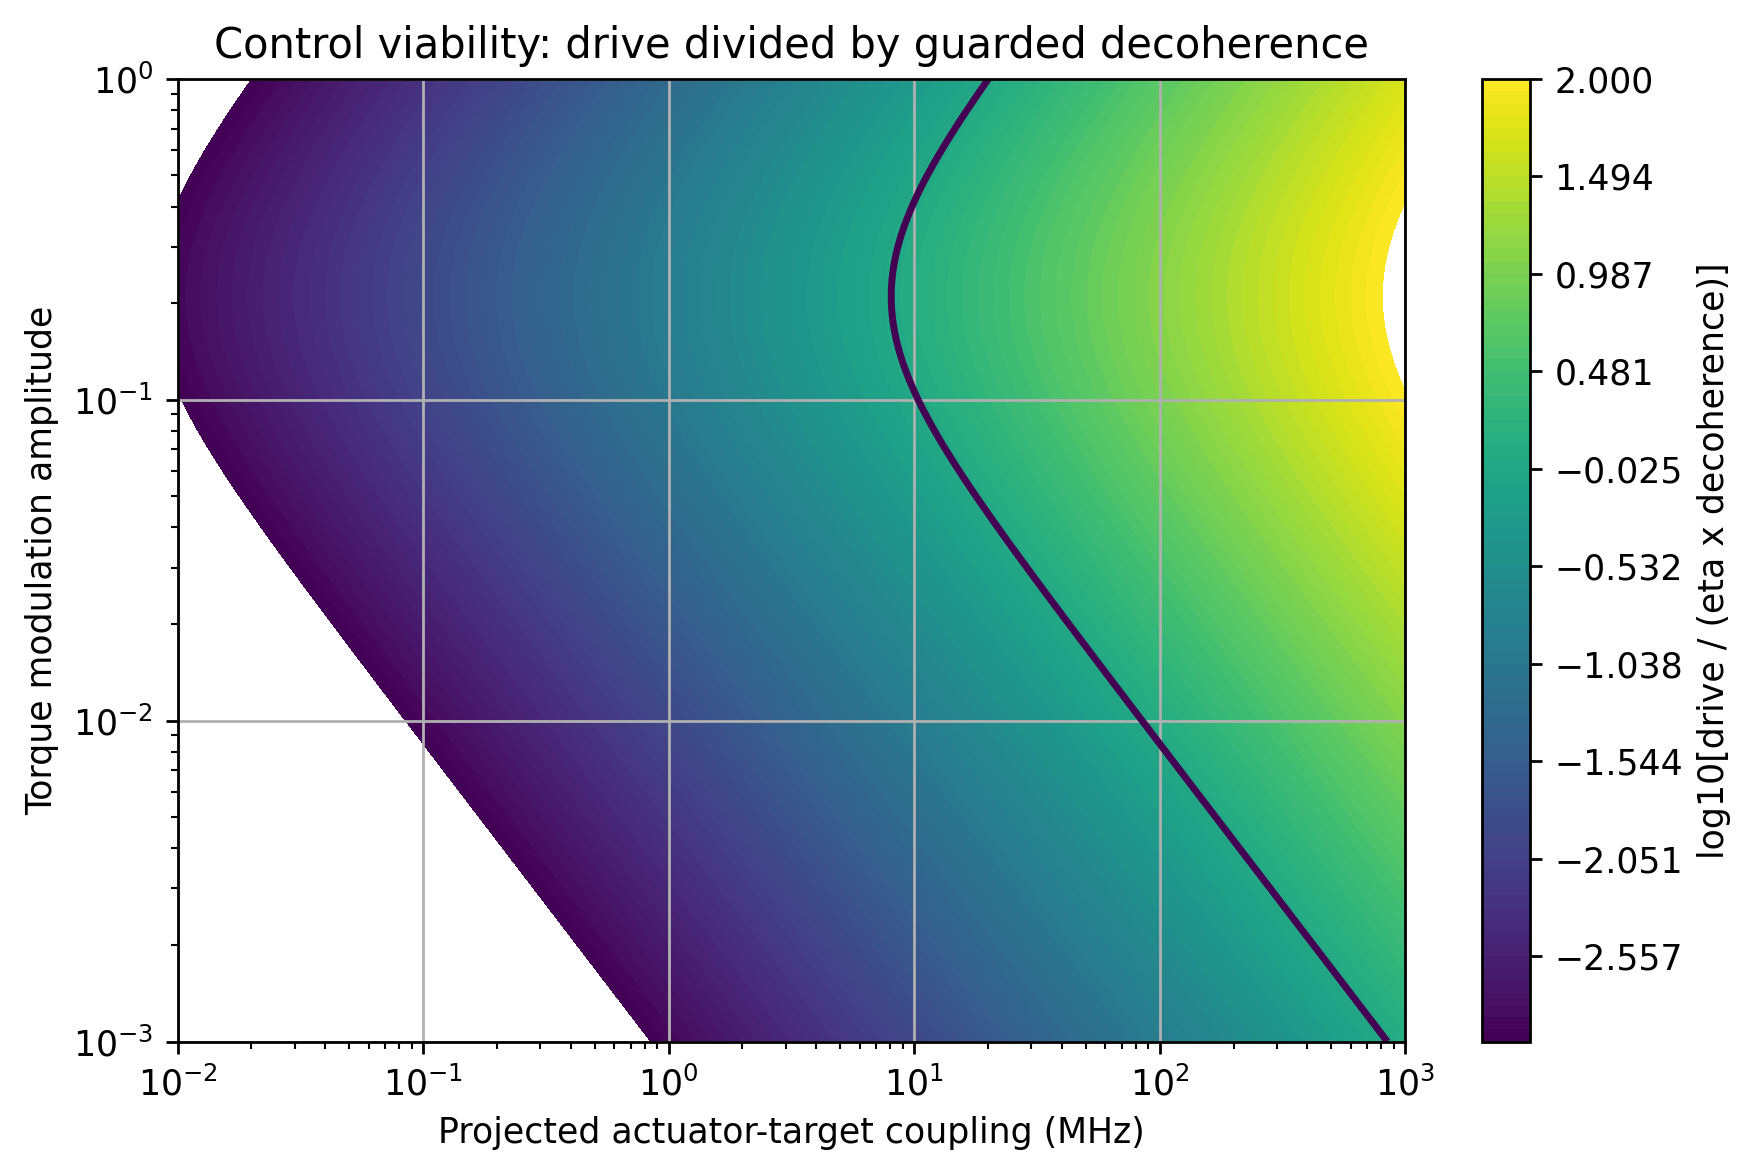

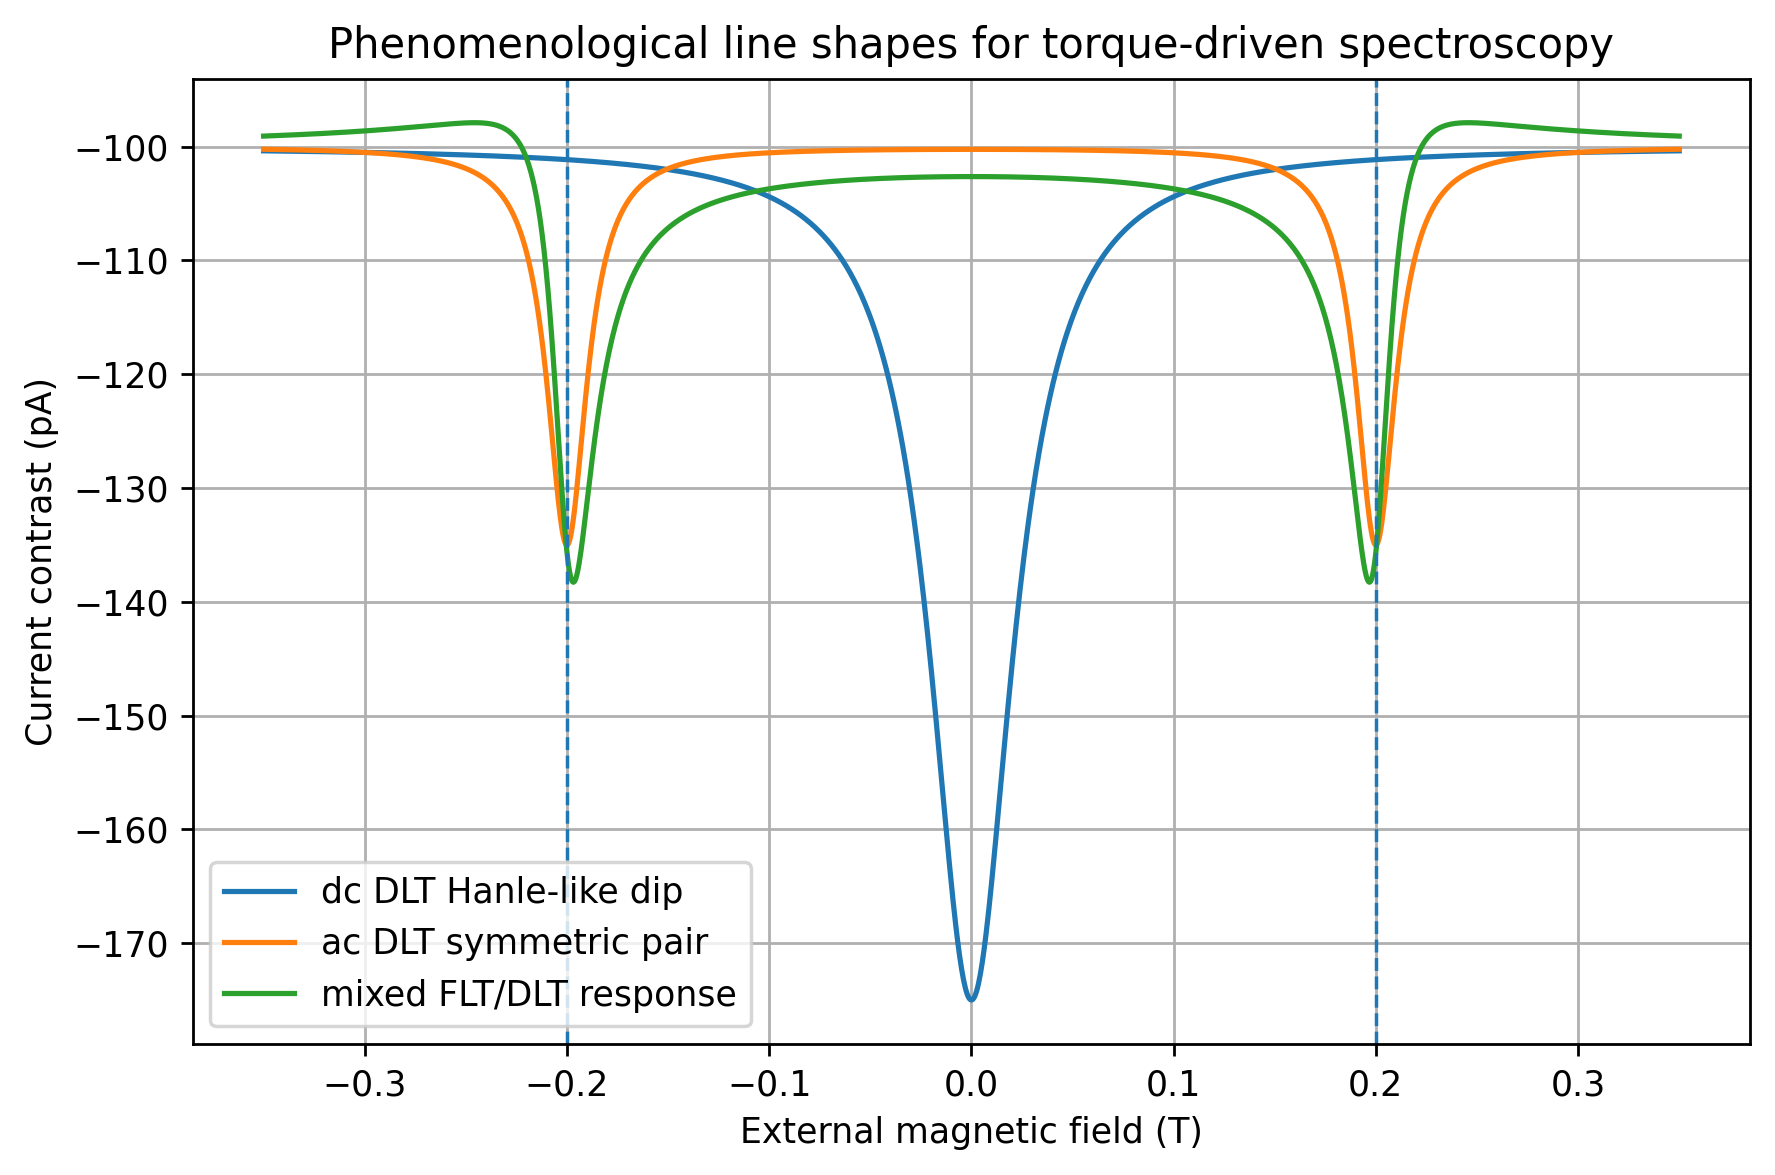

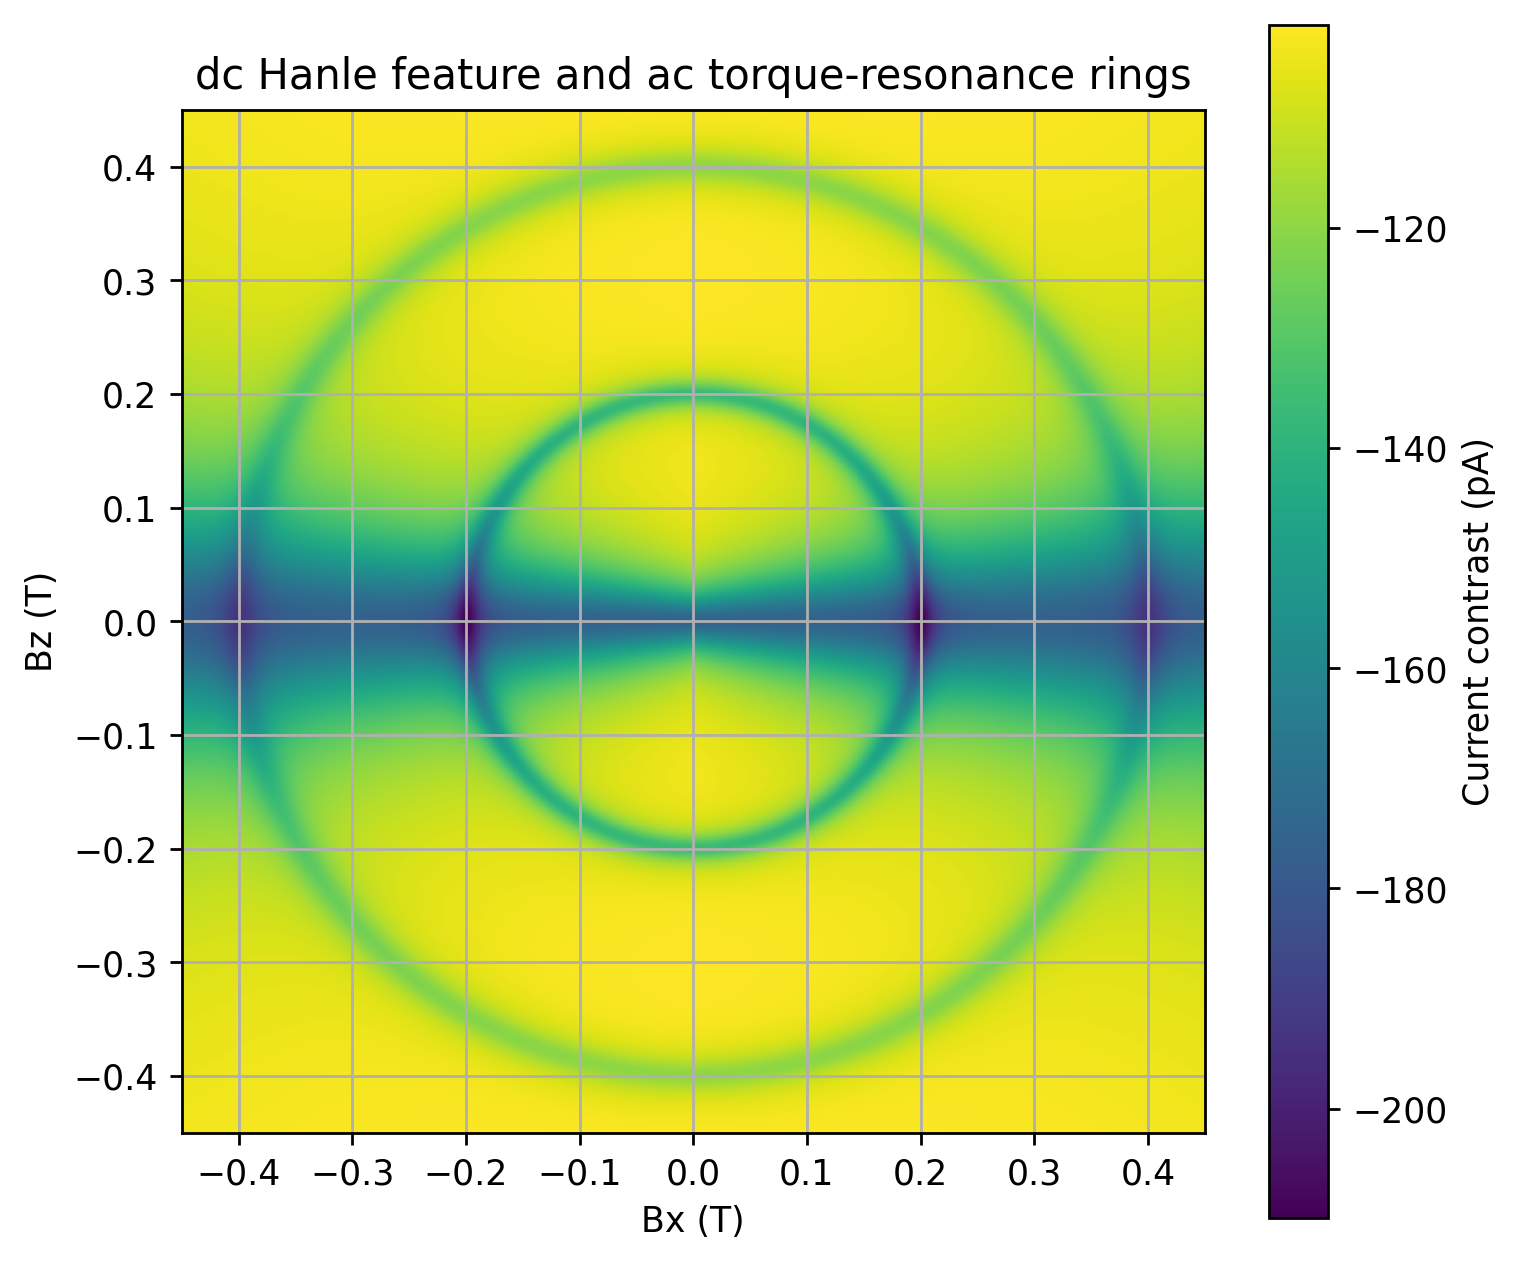

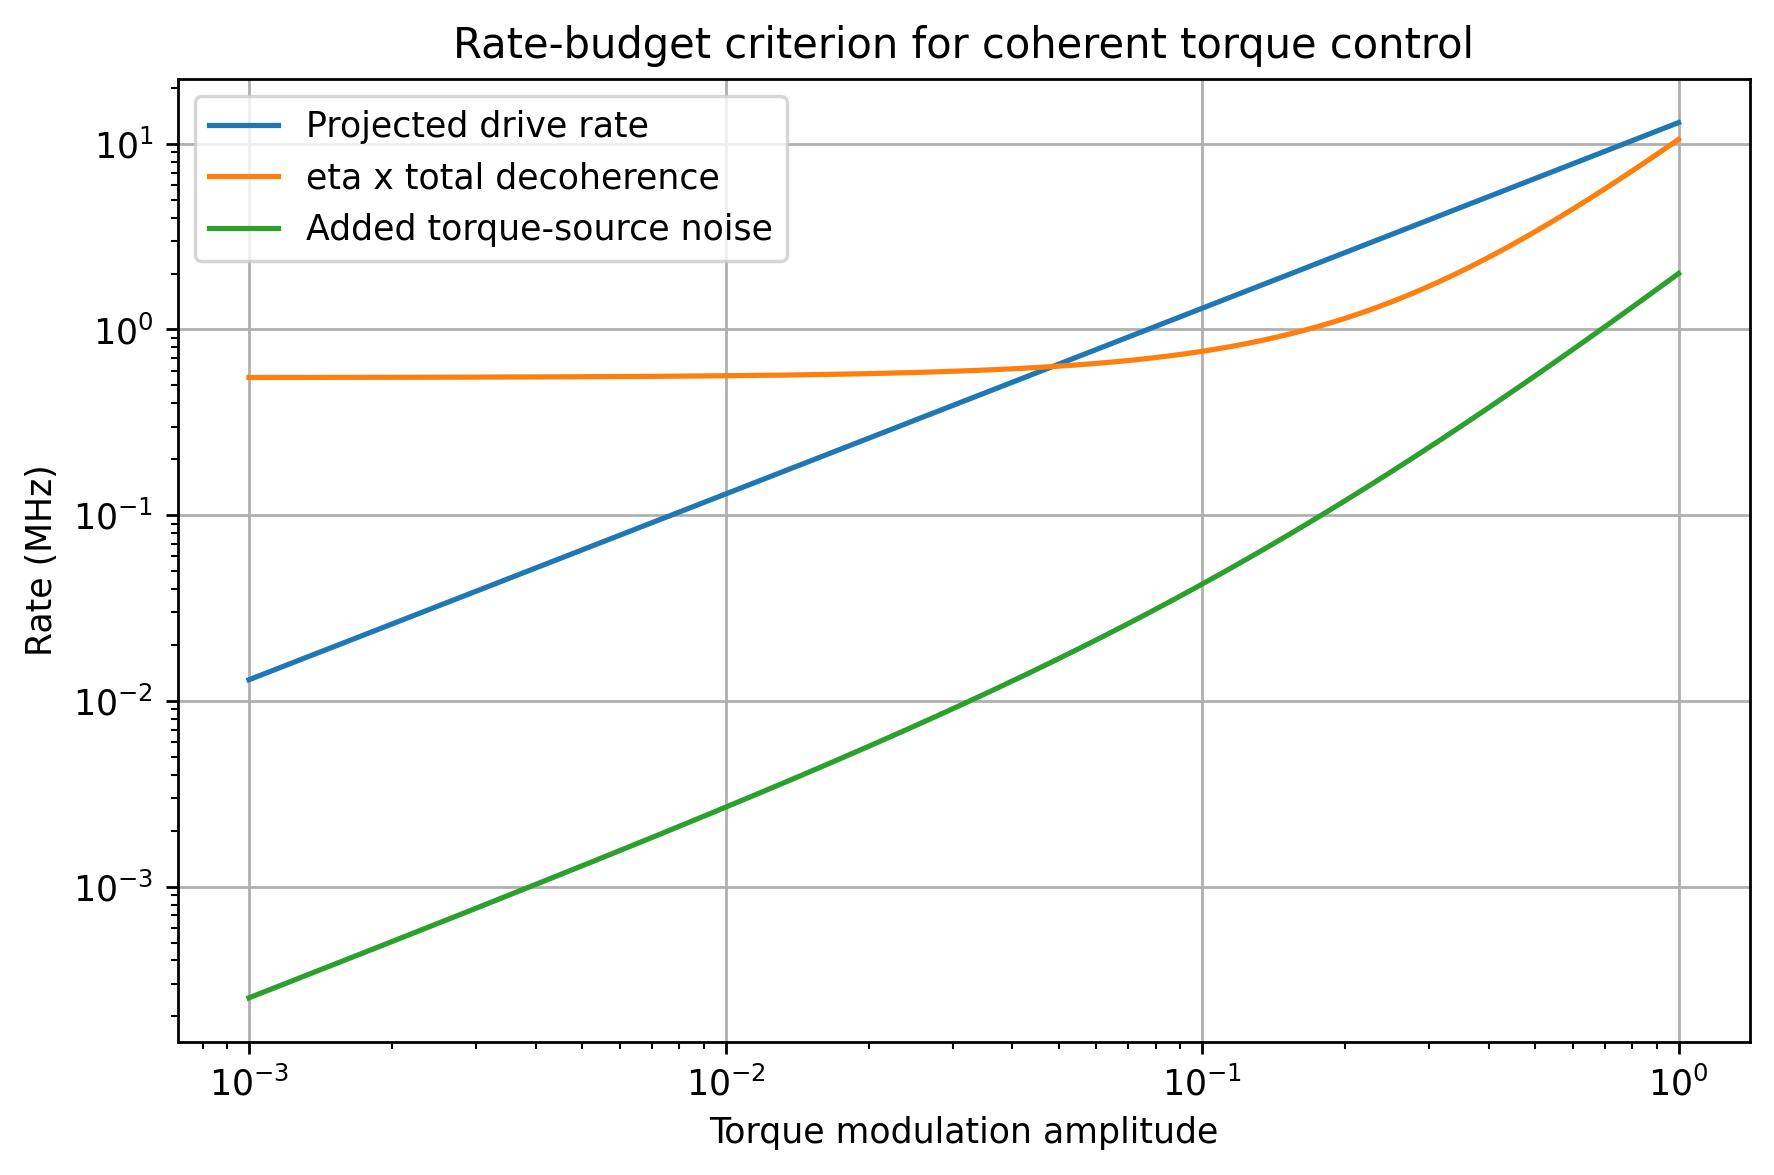

In [ ]:
"""Diagnostic plots for torque-based quantum-control proposals.

Run this script in Google Colab after adjusting the control knobs below.
"""

import importlib.util
import subprocess
import sys
from dataclasses import dataclass


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------
CONTROL = {
    "dpi": 250,
    "eta_gate_margin": 5.0,
    "intrinsic_decoherence_mhz": 0.08,
    "charge_noise_mhz": 0.03,
    "backaction_scale_mhz": 2.5,
    "target_overlap": 0.65,
    "resonance_field_t": 0.20,
    "dc_width_t": 0.025,
    "ac_width_t": 0.012,
    "baseline_current_pa": -100.0,
    "dc_contrast_pa": 75.0,
    "ac_contrast_pa": 35.0,
    "flt_dispersive_mix_pa": 20.0,
    "coupling_budget_mhz": 20.0,
    "dlt_linear_noise_mhz": 0.25,
    "thermal_quadratic_noise_mhz": 1.75,
}


@dataclass(frozen=True)
class ResonanceControls:
    """Control values used to synthesize resonance curves."""

    center_t: float
    dc_width_t: float
    ac_width_t: float
    baseline_pa: float
    dc_contrast_pa: float
    ac_contrast_pa: float
    flt_dispersive_mix_pa: float


@dataclass(frozen=True)
class BudgetControls:
    """Control values used for the drive-versus-noise budget."""

    eta_gate_margin: float
    intrinsic_decoherence_mhz: float
    charge_noise_mhz: float
    backaction_scale_mhz: float
    target_overlap: float
    coupling_budget_mhz: float
    dlt_linear_noise_mhz: float
    thermal_quadratic_noise_mhz: float


REQUIRED_PACKAGES = ("numpy", "matplotlib")


def ensure_dependencies() -> None:
    """Install missing dependencies with uv pip."""
    missing = [
        package
        for package in REQUIRED_PACKAGES
        if importlib.util.find_spec(package) is None
    ]
    if len(missing) == 0:
        return
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "uv"],
        check=True,
    )
    subprocess.run(
        ["uv", "pip", "install", "--system", *missing],
        check=True,
    )


ensure_dependencies()

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402

plt.rcParams["figure.dpi"] = CONTROL["dpi"]
plt.rcParams["savefig.dpi"] = CONTROL["dpi"]
plt.rcParams["axes.grid"] = True


def lorentzian(x_values: np.ndarray, center: float, width: float) -> np.ndarray:
    """Return a unit-height Lorentzian resonance."""
    return width**2 / ((x_values - center) ** 2 + width**2)


def dispersive(x_values: np.ndarray, center: float, width: float) -> np.ndarray:
    """Return a normalized dispersive resonance component."""
    denominator = (x_values - center) ** 2 + width**2
    return width * (x_values - center) / denominator


def make_resonance_controls() -> ResonanceControls:
    """Build resonance controls from the global control dictionary."""
    return ResonanceControls(
        center_t=CONTROL["resonance_field_t"],
        dc_width_t=CONTROL["dc_width_t"],
        ac_width_t=CONTROL["ac_width_t"],
        baseline_pa=CONTROL["baseline_current_pa"],
        dc_contrast_pa=CONTROL["dc_contrast_pa"],
        ac_contrast_pa=CONTROL["ac_contrast_pa"],
        flt_dispersive_mix_pa=CONTROL["flt_dispersive_mix_pa"],
    )


def make_budget_controls() -> BudgetControls:
    """Build rate-budget controls from the global control dictionary."""
    return BudgetControls(
        eta_gate_margin=CONTROL["eta_gate_margin"],
        intrinsic_decoherence_mhz=CONTROL["intrinsic_decoherence_mhz"],
        charge_noise_mhz=CONTROL["charge_noise_mhz"],
        backaction_scale_mhz=CONTROL["backaction_scale_mhz"],
        target_overlap=CONTROL["target_overlap"],
        coupling_budget_mhz=CONTROL["coupling_budget_mhz"],
        dlt_linear_noise_mhz=CONTROL["dlt_linear_noise_mhz"],
        thermal_quadratic_noise_mhz=CONTROL["thermal_quadratic_noise_mhz"],
    )


def plot_viability_map(controls: BudgetControls) -> None:
    """Plot projected drive rate divided by a guarded decoherence budget."""
    coupling_mhz = np.logspace(-2, 3, 320)
    modulation = np.logspace(-3, 0, 260)
    coupling_grid, modulation_grid = np.meshgrid(coupling_mhz, modulation)

    drive_mhz = controls.target_overlap * coupling_grid * modulation_grid
    decoherence_mhz = (
        controls.intrinsic_decoherence_mhz
        + controls.charge_noise_mhz
        + controls.backaction_scale_mhz * modulation_grid**2
    )
    score = drive_mhz / (controls.eta_gate_margin * decoherence_mhz)

    plt.figure(figsize=(7.2, 4.8))
    levels = np.linspace(-3.0, 2.0, 80)
    image = plt.contourf(
        coupling_grid,
        modulation_grid,
        np.log10(score),
        levels=levels,
    )
    plt.contour(
        coupling_grid,
        modulation_grid,
        score,
        levels=[1.0],
        linewidths=2.0,
    )
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Projected actuator-target coupling (MHz)")
    plt.ylabel("Torque modulation amplitude")
    plt.title("Control viability: drive divided by guarded decoherence")
    cbar = plt.colorbar(image)
    cbar.set_label("log10[drive / (eta x decoherence)]")
    plt.tight_layout()
    plt.show()


def plot_resonance_lines(controls: ResonanceControls) -> None:
    """Plot DLT, FLT, and mixed resonance line-shape diagnostics."""
    field_t = np.linspace(-0.35, 0.35, 1500)
    dc_line = controls.baseline_pa - controls.dc_contrast_pa * lorentzian(
        field_t,
        0.0,
        controls.dc_width_t,
    )
    ac_dlt = controls.baseline_pa - controls.ac_contrast_pa * (
        lorentzian(field_t, controls.center_t, controls.ac_width_t)
        + lorentzian(field_t, -controls.center_t, controls.ac_width_t)
    )
    mixed = ac_dlt + controls.flt_dispersive_mix_pa * (
        dispersive(field_t, controls.center_t, controls.ac_width_t)
        - dispersive(field_t, -controls.center_t, controls.ac_width_t)
    )

    plt.figure(figsize=(7.2, 4.8))
    plt.plot(field_t, dc_line, label="dc DLT Hanle-like dip")
    plt.plot(field_t, ac_dlt, label="ac DLT symmetric pair")
    plt.plot(field_t, mixed, label="mixed FLT/DLT response")
    plt.axvline(controls.center_t, linestyle="--", linewidth=1.0)
    plt.axvline(-controls.center_t, linestyle="--", linewidth=1.0)
    plt.xlabel("External magnetic field (T)")
    plt.ylabel("Current contrast (pA)")
    plt.title("Phenomenological line shapes for torque-driven spectroscopy")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_vector_hanle_map(controls: ResonanceControls) -> None:
    """Plot dc Hanle contrast and ac torque-resonance rings in vector field."""
    axis_t = np.linspace(-0.45, 0.45, 420)
    bx_grid, bz_grid = np.meshgrid(axis_t, axis_t)
    field_abs = np.sqrt(bx_grid**2 + bz_grid**2)

    dc_feature = controls.dc_contrast_pa * lorentzian(
        bz_grid,
        0.0,
        controls.dc_width_t * (1.0 + np.abs(bx_grid) / 0.15),
    )
    ac_feature = controls.ac_contrast_pa * lorentzian(
        field_abs,
        controls.center_t,
        controls.ac_width_t,
    )
    second_harmonic = 0.55 * controls.ac_contrast_pa * lorentzian(
        field_abs,
        2.0 * controls.center_t,
        1.4 * controls.ac_width_t,
    )
    current_pa = controls.baseline_pa - dc_feature - ac_feature - second_harmonic

    plt.figure(figsize=(6.2, 5.4))
    image = plt.imshow(
        current_pa,
        origin="lower",
        extent=[axis_t.min(), axis_t.max(), axis_t.min(), axis_t.max()],
        aspect="equal",
    )
    plt.xlabel("Bx (T)")
    plt.ylabel("Bz (T)")
    plt.title("dc Hanle feature and ac torque-resonance rings")
    cbar = plt.colorbar(image)
    cbar.set_label("Current contrast (pA)")
    plt.tight_layout()
    plt.show()


def plot_rate_budget(controls: BudgetControls) -> None:
    """Plot drive, guarded decoherence, and added noise versus drive strength."""
    modulation = np.logspace(-3, 0, 600)
    drive_mhz = (
        controls.target_overlap
        * controls.coupling_budget_mhz
        * modulation
    )
    added_noise_mhz = (
        controls.dlt_linear_noise_mhz * modulation
        + controls.thermal_quadratic_noise_mhz * modulation**2
    )
    total_decoherence_mhz = (
        controls.intrinsic_decoherence_mhz
        + controls.charge_noise_mhz
        + added_noise_mhz
    )
    guarded_decoherence_mhz = controls.eta_gate_margin * total_decoherence_mhz

    plt.figure(figsize=(7.2, 4.8))
    plt.loglog(modulation, drive_mhz, label="Projected drive rate")
    plt.loglog(
        modulation,
        guarded_decoherence_mhz,
        label="eta x total decoherence",
    )
    plt.loglog(modulation, added_noise_mhz, label="Added torque-source noise")
    plt.xlabel("Torque modulation amplitude")
    plt.ylabel("Rate (MHz)")
    plt.title("Rate-budget criterion for coherent torque control")
    plt.legend()
    plt.tight_layout()
    plt.show()


def main() -> None:
    """Render all diagnostic plots."""
    resonance_controls = make_resonance_controls()
    budget_controls = make_budget_controls()
    plot_viability_map(budget_controls)
    plot_resonance_lines(resonance_controls)
    plot_vector_hanle_map(resonance_controls)
    plot_rate_budget(budget_controls)


if __name__ == "__main__":
    main()

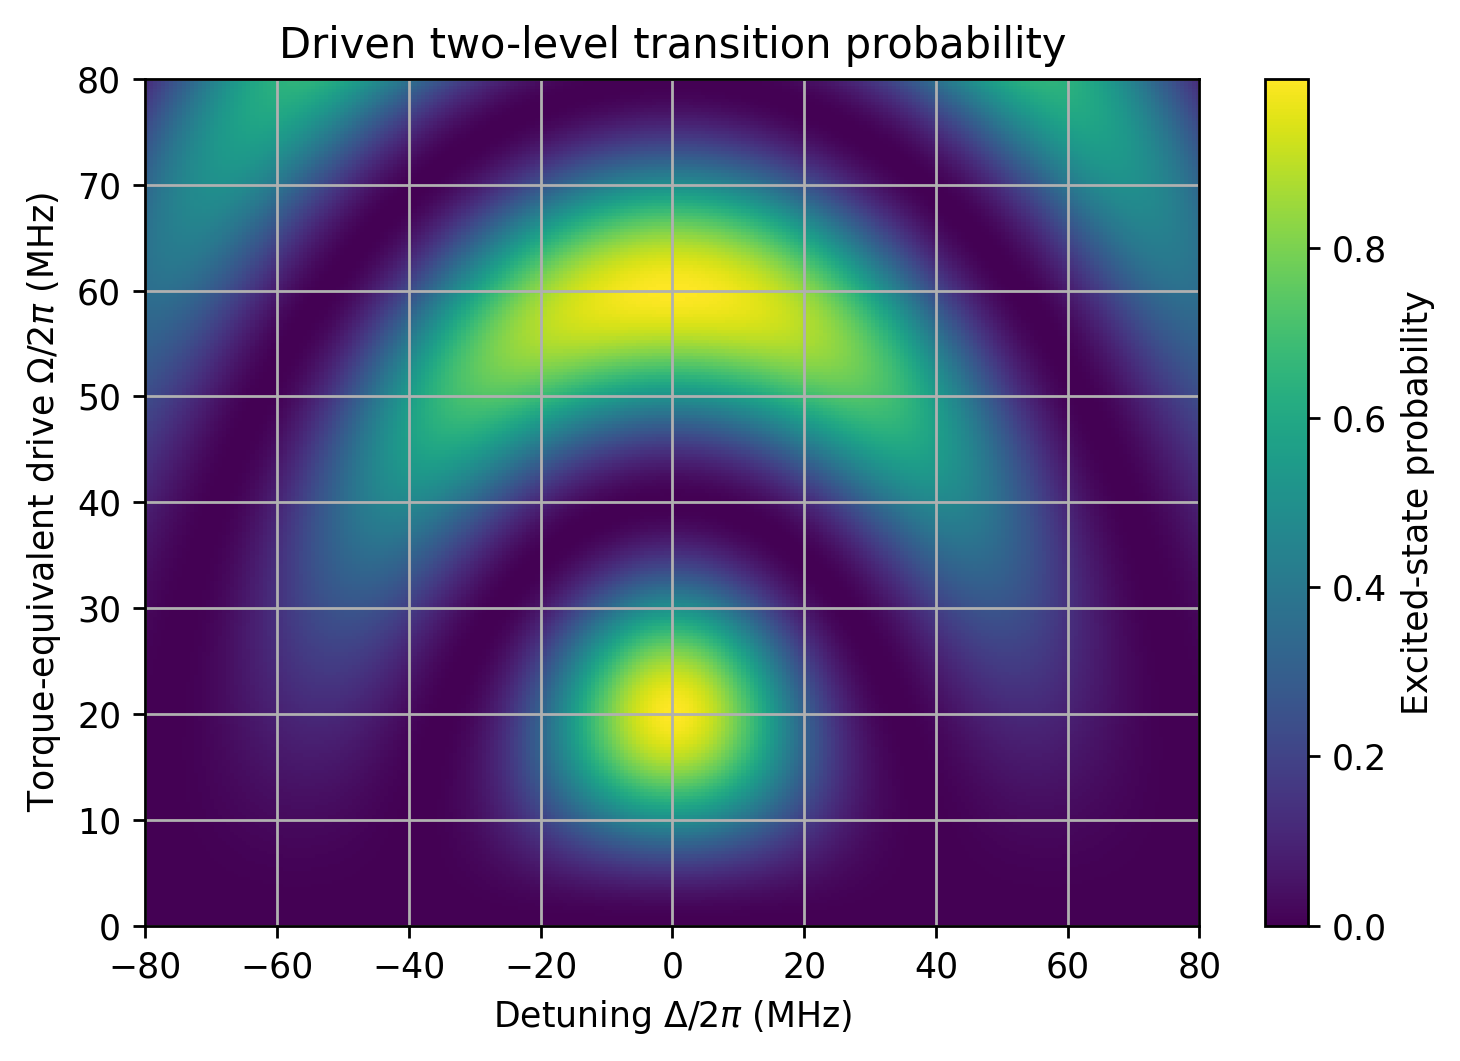

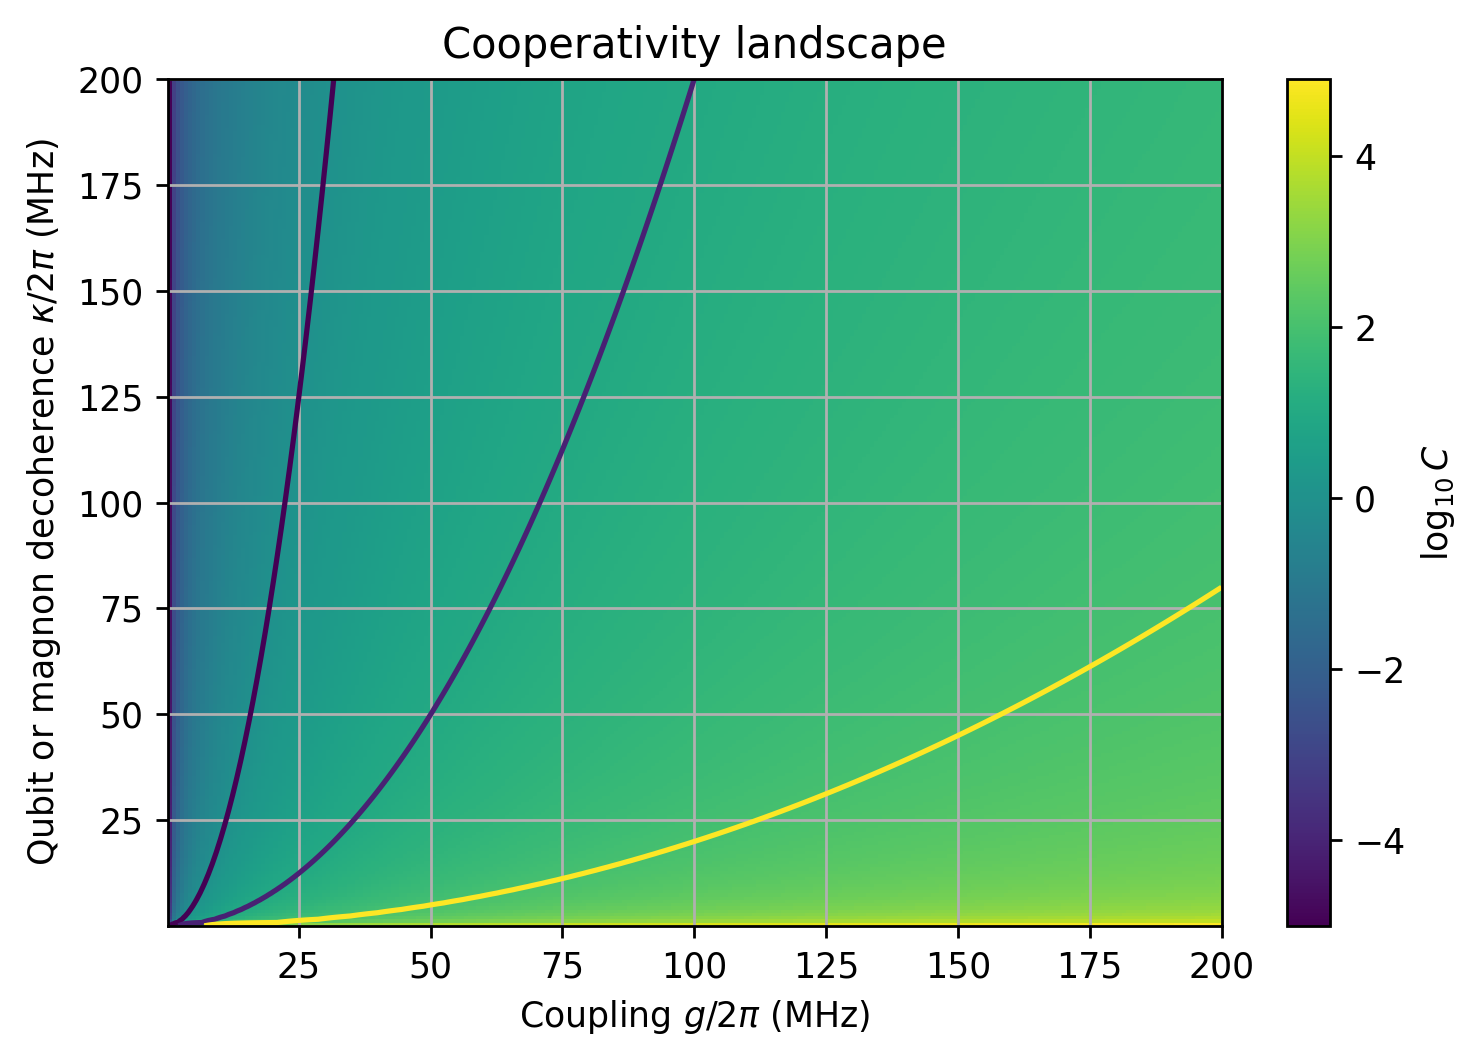

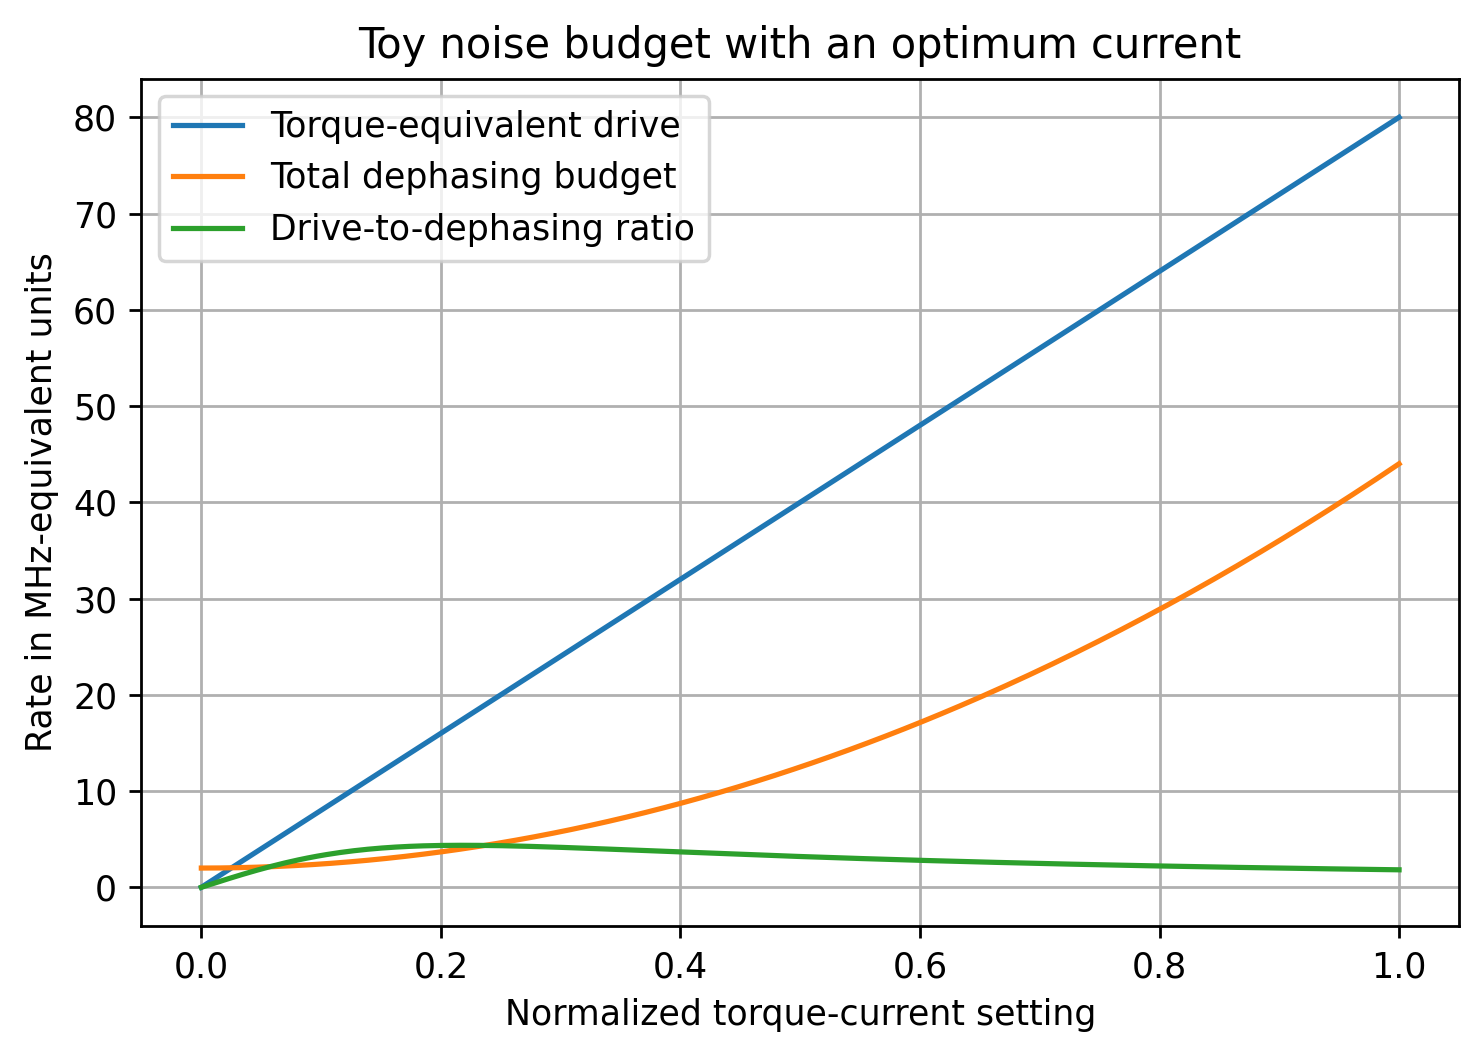

In [3]:
"""Plots for torque-driven quantum-control estimates.
"""

import matplotlib.pyplot as plt
import numpy as np

# Control knobs
PULSE_DURATION_NS = 25.0
DETUNING_RANGE_MHZ = (-80.0, 80.0)
DRIVE_RANGE_MHZ = (0.0, 80.0)
GRID_POINTS = 260
READOUT_LINEWIDTH_MHZ = 5.0
COUPLING_RANGE_MHZ = (0.1, 200.0)
DECOHERENCE_RANGE_MHZ = (0.1, 200.0)
DEPHASING_BASE_MHZ = 2.0
JOULE_DEPHASING_MHZ = 42.0
MAX_DRIVE_MHZ = 80.0

plt.rcParams["figure.dpi"] = 250


def rabi_probability(
    rabi_mhz: np.ndarray,
    detuning_mhz: np.ndarray,
    pulse_duration_ns: float,
) -> np.ndarray:
    """Return transition probability for a driven two-level system.

    Args:
        rabi_mhz: Torque-equivalent Rabi frequency in MHz.
        detuning_mhz: Drive detuning in MHz.
        pulse_duration_ns: Pulse duration in nanoseconds.

    Returns:
        Excited-state probability evaluated at the pulse end.
    """
    omega = 2.0 * np.pi * rabi_mhz * 1.0e-3
    delta = 2.0 * np.pi * detuning_mhz * 1.0e-3
    generalized = np.sqrt(omega**2 + delta**2)
    prefactor = np.divide(
        omega**2,
        generalized**2,
        out=np.zeros_like(generalized),
        where=generalized > 0.0,
    )
    return prefactor * np.sin(0.5 * generalized * pulse_duration_ns) ** 2


def cooperativity(
    coupling_mhz: np.ndarray,
    linewidth_one_mhz: float,
    linewidth_two_mhz: np.ndarray,
) -> np.ndarray:
    """Return hybrid cooperativity for two lossy modes.

    Args:
        coupling_mhz: Coupling rate g divided by 2 pi in MHz.
        linewidth_one_mhz: First linewidth divided by 2 pi in MHz.
        linewidth_two_mhz: Second linewidth divided by 2 pi in MHz.

    Returns:
        Dimensionless cooperativity C = g^2 / (kappa_1 kappa_2).
    """
    return coupling_mhz**2 / (linewidth_one_mhz * linewidth_two_mhz)


def render_rabi_map() -> None:
    """Render a detuning-drive chevron for a torque-equivalent pulse."""
    detuning = np.linspace(*DETUNING_RANGE_MHZ, GRID_POINTS)
    drive = np.linspace(*DRIVE_RANGE_MHZ, GRID_POINTS)
    detuning_grid, drive_grid = np.meshgrid(detuning, drive)
    probability = rabi_probability(
        drive_grid,
        detuning_grid,
        PULSE_DURATION_NS,
    )

    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    image = ax.imshow(
        probability,
        origin="lower",
        aspect="auto",
        extent=[detuning.min(), detuning.max(), drive.min(), drive.max()],
    )
    ax.set_xlabel(r"Detuning $\Delta/2\pi$ (MHz)")
    ax.set_ylabel(r"Torque-equivalent drive $\Omega/2\pi$ (MHz)")
    ax.set_title("Driven two-level transition probability")
    fig.colorbar(image, ax=ax, label="Excited-state probability")
    plt.show()


def render_cooperativity_map() -> None:
    """Render the cooperativity landscape for hybrid quantum exchange."""
    coupling = np.linspace(*COUPLING_RANGE_MHZ, GRID_POINTS)
    decoherence = np.linspace(*DECOHERENCE_RANGE_MHZ, GRID_POINTS)
    coupling_grid, decoherence_grid = np.meshgrid(coupling, decoherence)
    coop = cooperativity(
        coupling_grid,
        READOUT_LINEWIDTH_MHZ,
        decoherence_grid,
    )

    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    image = ax.imshow(
        np.log10(coop),
        origin="lower",
        aspect="auto",
        extent=[coupling.min(), coupling.max(), decoherence.min(), decoherence.max()],
    )
    ax.contour(coupling_grid, decoherence_grid, coop, levels=[1.0, 10.0, 100.0])
    ax.set_xlabel(r"Coupling $g/2\pi$ (MHz)")
    ax.set_ylabel(r"Qubit or magnon decoherence $\kappa/2\pi$ (MHz)")
    ax.set_title("Cooperativity landscape")
    fig.colorbar(image, ax=ax, label=r"$\log_{10} C$")
    plt.show()


def render_noise_budget() -> None:
    """Render an illustrative drive and dephasing budget."""
    current = np.linspace(0.0, 1.0, GRID_POINTS)
    drive_rate = MAX_DRIVE_MHZ * current
    dephasing = DEPHASING_BASE_MHZ + JOULE_DEPHASING_MHZ * current**2
    coherent_ratio = drive_rate / dephasing

    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    ax.plot(current, drive_rate, label="Torque-equivalent drive")
    ax.plot(current, dephasing, label="Total dephasing budget")
    ax.plot(current, coherent_ratio, label="Drive-to-dephasing ratio")
    ax.set_xlabel("Normalized torque-current setting")
    ax.set_ylabel("Rate in MHz-equivalent units")
    ax.set_title("Toy noise budget with an optimum current")
    ax.legend(loc="best")
    plt.show()


def main() -> None:
    """Render all plots as separate figures."""
    render_rabi_map()
    render_cooperativity_map()
    render_noise_budget()


if __name__ == "__main__":
    main()